In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Reading the file
df = pd.read_csv('Data & Resources/Data/Customer_Data.csv')

In [3]:
# Quick Look

df.head()


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


In [4]:
# info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6418 entries, 0 to 6417
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6418 non-null   object 
 1   Gender                       6418 non-null   object 
 2   Age                          6418 non-null   int64  
 3   Married                      6418 non-null   object 
 4   State                        6418 non-null   object 
 5   Number_of_Referrals          6418 non-null   int64  
 6   Tenure_in_Months             6418 non-null   int64  
 7   Value_Deal                   2870 non-null   object 
 8   Phone_Service                6418 non-null   object 
 9   Multiple_Lines               5796 non-null   object 
 10  Internet_Service             6418 non-null   object 
 11  Internet_Type                5028 non-null   object 
 12  Online_Security              5028 non-null   object 
 13  Online_Backup     

In [5]:
# Null values
df.isnull().sum()

Customer_ID                       0
Gender                            0
Age                               0
Married                           0
State                             0
Number_of_Referrals               0
Tenure_in_Months                  0
Value_Deal                     3548
Phone_Service                     0
Multiple_Lines                  622
Internet_Service                  0
Internet_Type                  1390
Online_Security                1390
Online_Backup                  1390
Device_Protection_Plan         1390
Premium_Support                1390
Streaming_TV                   1390
Streaming_Movies               1390
Streaming_Music                1390
Unlimited_Data                 1390
Contract                          0
Paperless_Billing                 0
Payment_Method                    0
Monthly_Charge                    0
Total_Charges                     0
Total_Refunds                     0
Total_Extra_Data_Charges          0
Total_Long_Distance_Charges 

In [6]:
df.columns

Index(['Customer_ID', 'Gender', 'Age', 'Married', 'State',
       'Number_of_Referrals', 'Tenure_in_Months', 'Value_Deal',
       'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type',
       'Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
       'Payment_Method', 'Monthly_Charge', 'Total_Charges', 'Total_Refunds',
       'Total_Extra_Data_Charges', 'Total_Long_Distance_Charges',
       'Total_Revenue', 'Customer_Status', 'Churn_Category', 'Churn_Reason'],
      dtype='object')

In [7]:
# Handiling Null values

df['Value_Deal'] = df['Value_Deal'].fillna('None')
df['Internet_Type'] = df['Internet_Type'].fillna('None')
df['Churn_Category'] = df['Churn_Category'].fillna('Not Applicable')
df['Churn_Reason'] = df['Churn_Reason'].fillna('Not Applicabe')

columns = ['Multiple_Lines','Online_Security', 'Online_Backup', 'Device_Protection_Plan',
       'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
       'Streaming_Music', 'Unlimited_Data']

for col in columns:
    df[col] = df[col].fillna('No')

print(df.isnull().sum())

Customer_ID                    0
Gender                         0
Age                            0
Married                        0
State                          0
Number_of_Referrals            0
Tenure_in_Months               0
Value_Deal                     0
Phone_Service                  0
Multiple_Lines                 0
Internet_Service               0
Internet_Type                  0
Online_Security                0
Online_Backup                  0
Device_Protection_Plan         0
Premium_Support                0
Streaming_TV                   0
Streaming_Movies               0
Streaming_Music                0
Unlimited_Data                 0
Contract                       0
Paperless_Billing              0
Payment_Method                 0
Monthly_Charge                 0
Total_Charges                  0
Total_Refunds                  0
Total_Extra_Data_Charges       0
Total_Long_Distance_Charges    0
Total_Revenue                  0
Customer_Status                0
Churn_Cate

In [25]:
df.to_csv('Customer_Data_cleaned',index = False)

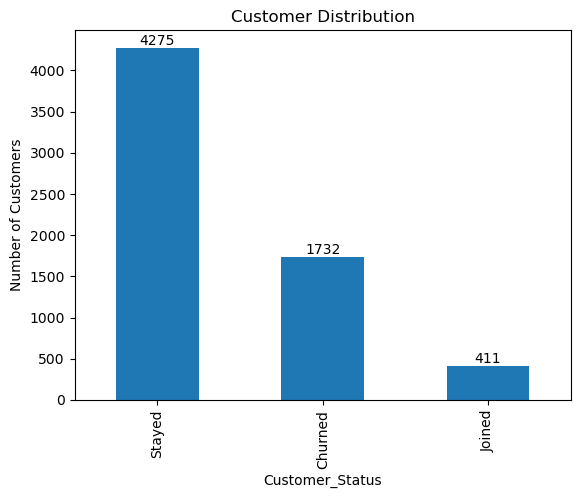

In [24]:
# Churn Distribution

# df['Customer_Status'].value_counts().plot(kind='bar',ylabel='Count')
# plt.show()

ax = df['Customer_Status'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])

plt.xlabel('Customer_Status')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution')
plt.show()

# counts = df['Customer_Status'].value_counts()

# ax = counts.plot(kind='bar')

# # add labels on top of bars
# for bar in ax.patches:
#     ax.text(
#         bar.get_x() + bar.get_width() / 2,
#         bar.get_height(),
#         int(bar.get_height()),
#         ha='center',
#         va='bottom'
#     )

# plt.xlabel('Customer Status')
# plt.ylabel('Number of Customers')
# plt.title('Customer Distribution')
# plt.show()

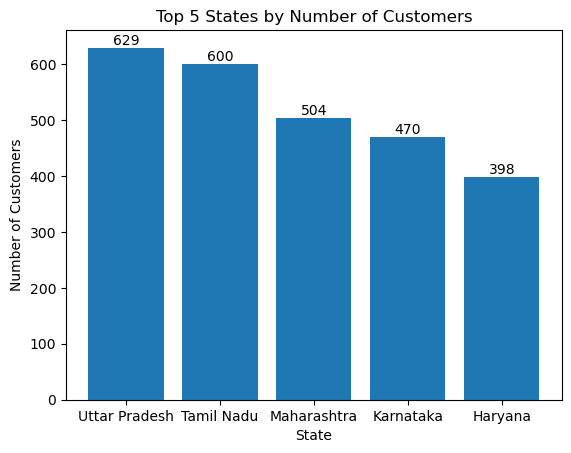

In [25]:
# top 5 states 

counts = df['State'].value_counts().head(5)

plt.bar(counts.index, counts.values)

for i in range(len(counts)):
    plt.text(counts.index[i], counts.values[i], counts.values[i],
             ha='center', va='bottom')

plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Top 5 States by Number of Customers')
plt.show()

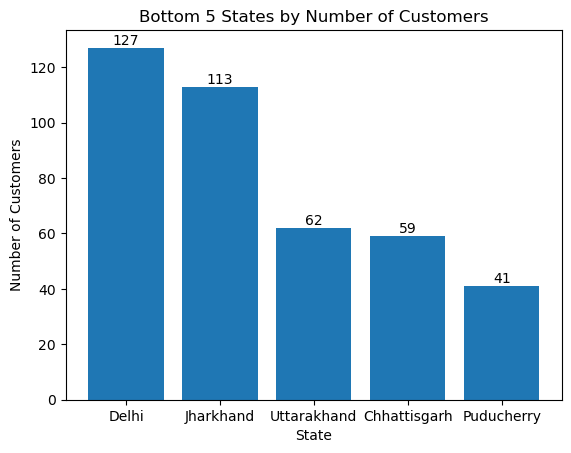

In [26]:
# bottom 5 states
counts = df['State'].value_counts().tail(5)

plt.bar(counts.index, counts.values)

for i in range(len(counts)):
    plt.text(counts.index[i], counts.values[i], counts.values[i],
             ha='center', va='bottom')

plt.xlabel('State')
plt.ylabel('Number of Customers')
plt.title('Bottom 5 States by Number of Customers')
plt.show()

In [27]:
df_churned_data = df[(df['Customer_Status'] == 'Churned') | (df['Customer_Status']=='Stayed')]
df_joined_data = df[df['Customer_Status'] == 'Joined']

In [28]:
df_churned_data.to_excel('Churned_Data.xlsx',index=False)

In [29]:
df_joined_data.to_excel('Joined_Data.xlsx',index=False)